# Assignment 1 - AcnEmphathize Dataset

**Course:** Natural Language Processing

**Group:** 12

    Guilherme Oliveira: 202204987
    Magda Costa: 202207036

---

# Index  <a name = "index"></a>
1. [Preprocessing variations for AcnEmpathize](#pva)
    - [Research question and hypothesis](#rqah)
    - [Experimental design](#ed)
    - [NLP resources](nlp_r)
    - [Load the dataset](#ld)
    - [Initial filtering shared by all experiments](ifsbae)
    - [Train/test split](#tts)
    - [Define preprocessing functions](#dpf)
    - [Model setup](#ms)
    - [Evaluation function](#ef)
    - [Run the preprocessing variation experiments](#rpve)
    - [Rank the preprocessing variants](#rpv)
    - [Visual comparison of the main metrics](#vcmm)
    - [Confusion matrices](#cm)
2. [Conclusions](#c)

---

# Preprocessing variations for AcnEmpathize <a name = "pva"></a>

This notebook investigates **whether changing preprocessing improves the best classical model from Section 2**.

In the baseline model comparison, **Logistic Regression** was the strongest classical model.  
So, in this notebook, we **fix the model** and vary only the preprocessing strategy.

The goal is not to find the final best possible system yet.  
The goal is to answer a more focused question:

> **How sensitive is empathy detection performance to different preprocessing choices?**

## 1. Research question and hypothesis <a name = "rqah"></a>

### Research question
If we keep the **same classifier** and the **same TF-IDF representation**, does changing preprocessing improve empathy detection?

### Hypothesis
Because empathy can be expressed through short personal expressions, informal writing, and emotional markers, preprocessing may have a strong effect on the minority class.

We test the following expectations:

- **P1 — baseline cleaning**: should reproduce the reference setup and serve as the comparison point.
- **P2 — keep stopwords**: may help because empathy often relies on pronouns and function words such as *I*, *you*, *we*, *it*, *that*, and short supportive phrases.
- **P3 — stemming instead of lemmatization**: may help if aggressive normalization groups related word forms, but it may also hurt if it removes useful nuance.
- **P4 — minimal cleaning**: may preserve informal cues that heavier preprocessing removes, but may also increase noise.

### Experimental principle
To make the comparison fair, we keep everything else fixed:
- same dataset,
- same train/test split,
- same TF-IDF settings,
- same model,
- same evaluation metrics.

That way, any change in performance can be attributed mainly to preprocessing.

## 2. Experimental design <a name = "ed"></a>

We test five preprocessing variants:

| Group | Preprocessing | Features | Model | Purpose |
|---|---|---|---|---|
| P1 | baseline cleaning | TF-IDF | Logistic Regression | reference |
| P2 | keep stopwords | TF-IDF | Logistic Regression | empathy may use pronouns |
| P3 | stemming instead of lemmatization | TF-IDF | Logistic Regression | test normalization |
| P4 | minimal cleaning | TF-IDF | Logistic Regression | avoid losing signal |

The baseline cleaning follows the paper-oriented setup we used before:
- newline cleanup,
- keep only posts with at least one alphabetical token,
- lowercase,
- punctuation removal,
- stopword removal,
- lemmatization.

The paper explicitly describes newline cleanup and keeping posts with at least one alphabetical token in dataset preprocessing, and it also reports lowercasing, punctuation removal, stopword removal, and lemmatization for dataset content analysis. We use that same classical preprocessing family here as the **reference condition**.

In [1]:
# Core libraries
import re
import string
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## 3. NLP resources <a name = "nlp_r"></a>

We use NLTK for:
- stopwords,
- tokenization,
- lemmatization,
- stemming.

The resources are downloaded only if needed so the notebook remains reproducible.

In [2]:
import nltk

resources = {
    "tokenizers/punkt": "punkt",
    "tokenizers/punkt_tab": "punkt_tab",
    "corpora/stopwords": "stopwords",
    "corpora/wordnet": "wordnet",
    "corpora/omw-1.4": "omw-1.4",
}

for resource_path, resource_name in resources.items():
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(resource_name)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

[nltk_data] Downloading package wordnet to /Users/gjoli/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/gjoli/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 4. Load the dataset <a name = "ld"></a>

We use the same dataset path convention as in the EDA and baseline notebooks.

This keeps the workflow consistent across sections of the project.

In [3]:
df = pd.read_csv("AcnEmpathize_dataset.csv")
data = df[['text', 'combined_empathy']].copy()
data = data.rename(columns={'combined_empathy': 'label'})
data.head()

,text,label
0,"Hello! I've been having a hard time, lingeri...",0
1,"Hey man the pictures are not present, can you ...",0
2,There are many many many many many many many d...,0
3,Maybe in some African tribe my face scars woul...,0
4,None of those opinions consider acne to be bea...,0


## 5. Initial filtering shared by all experiments <a name = "ifsbae"></a>

Before testing preprocessing variants, we apply the same very first dataset-level filter used in the paper-oriented setup:

- replace newline characters,
- keep only posts containing **at least one alphabetical token**.

This step is shared by all variants because it is part of the corpus preparation logic rather than one of the experimental preprocessing variations.

In [4]:
def normalize_newlines(text: str) -> str:
    return re.sub(r"[\r\n]+", " ", str(text)).strip()

def has_alphabetical_token(text: str) -> bool:
    return bool(re.search(r"[A-Za-z]+", str(text)))

data["text"] = data["text"].apply(normalize_newlines)
data = data[data["text"].apply(has_alphabetical_token)].copy()

print("Shape after shared filtering:", data.shape)
print(data["label"].value_counts().sort_index())

Shape after shared filtering: (12212, 2)
label
0    9236
1    2976
Name: count, dtype: int64


## 6. Train/test split <a name = "tts"></a>

We use a **stratified split** so the class proportions remain similar in train and test sets.  
This is important because the dataset is imbalanced.

We create the split **once** and reuse it for every preprocessing variant.  
That ensures a fair comparison.

In [5]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Train size: 9769
Test size: 2443

Train label distribution:
label
0    0.75627
1    0.24373
Name: proportion, dtype: float64

Test label distribution:
label
0    0.756447
1    0.243553
Name: proportion, dtype: float64


## 7. Define preprocessing functions <a name = "dpf"></a>

Now we implement the five preprocessing strategies.

### Variant definitions
- **P1 baseline cleaning**: lowercase + punctuation removal + stopword removal + lemmatization
- **P2 keep stopwords**: same as baseline, but preserve stopwords
- **P3 stemming**: same as baseline, but replace lemmatization with stemming
- **P4 minimal cleaning**: only lowercase and whitespace cleanup after the shared dataset filtering
- **P5 emoji normalization**: baseline cleaning plus conversion of emojis into text labels before token processing

In [6]:
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def clean_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", str(text)).strip()

def tokenize_basic(text: str):
    return word_tokenize(text)

def preprocess_baseline(text: str) -> str:
    text = str(text).lower()
    text = text.translate(PUNCT_TABLE)
    tokens = tokenize_basic(text)
    tokens = [tok for tok in tokens if tok.isalpha()]
    tokens = [tok for tok in tokens if tok not in STOPWORDS]
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(tokens)

def preprocess_keep_stopwords(text: str) -> str:
    text = str(text).lower()
    text = text.translate(PUNCT_TABLE)
    tokens = tokenize_basic(text)
    tokens = [tok for tok in tokens if tok.isalpha()]
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(tokens)

def preprocess_stemming(text: str) -> str:
    text = str(text).lower()
    text = text.translate(PUNCT_TABLE)
    tokens = tokenize_basic(text)
    tokens = [tok for tok in tokens if tok.isalpha()]
    tokens = [tok for tok in tokens if tok not in STOPWORDS]
    tokens = [stemmer.stem(tok) for tok in tokens]
    return " ".join(tokens)

def preprocess_minimal(text: str) -> str:
    text = str(text).lower()
    text = clean_whitespace(text)
    return text

def preprocess_emoji_normalization(text: str) -> str:
    text = str(text).replace(":", " ")
    text = text.lower()
    text = text.translate(PUNCT_TABLE)
    tokens = tokenize_basic(text)
    tokens = [tok for tok in tokens if tok.isalpha()]
    tokens = [tok for tok in tokens if tok not in STOPWORDS]
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(tokens)

PREPROCESSORS = {
    "P1_baseline_cleaning": preprocess_baseline,
    "P2_keep_stopwords": preprocess_keep_stopwords,
    "P3_stemming": preprocess_stemming,
    "P4_minimal_cleaning": preprocess_minimal,
}

## 9. Model setup <a name = "ms"></a>

We now fix the **same classifier for all experiments**: Logistic Regression.

We also keep the feature extraction fixed:
- **TF-IDF**
- **unigrams**
- **max_features = 5000**

This matches the logic of the previous section: only preprocessing changes here.

In [7]:
def build_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 1))),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ])

## 10. Evaluation function <a name = "ef"></a>

To compare preprocessing choices properly, we compute the same metrics for each experiment:

- accuracy,
- macro-F1,
- empathy precision / recall / F1,
- no-empathy precision / recall / F1.

Macro-F1 is especially important because the classes are imbalanced.

In [8]:
def evaluate_predictions(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1, 0], zero_division=0
    )

    macro_f1 = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )[2]

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "precision_empathy": precision[0],
        "recall_empathy": recall[0],
        "f1_empathy": f1[0],
        "precision_no_empathy": precision[1],
        "recall_no_empathy": recall[1],
        "f1_no_empathy": f1[1],
    }

## 11. Run the preprocessing variation experiments <a name = "rpve"></a>

For each experiment:
1. preprocess the training and test text with the selected variant,
2. fit the same TF-IDF + Logistic Regression pipeline,
3. predict on the test set,
4. store the metrics and confusion matrix.

Because the split and model are fixed, this gives us a clean ablation study focused on preprocessing only.

In [9]:
results = []
predictions = {}
processed_examples = {}

for exp_name, preprocess_fn in PREPROCESSORS.items():
    X_train_proc = X_train.apply(preprocess_fn)
    X_test_proc = X_test.apply(preprocess_fn)

    processed_examples[exp_name] = {
        "train_nonempty_ratio": (X_train_proc.str.len() > 0).mean(),
        "test_nonempty_ratio": (X_test_proc.str.len() > 0).mean(),
        "avg_train_length_chars": X_train_proc.str.len().mean(),
        "avg_test_length_chars": X_test_proc.str.len().mean(),
    }

    model = build_pipeline()
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_test_proc)

    predictions[exp_name] = y_pred
    metrics = evaluate_predictions(y_test, y_pred)
    metrics["experiment"] = exp_name
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df = results_df[
    [
        "experiment",
        "accuracy",
        "macro_f1",
        "precision_empathy",
        "recall_empathy",
        "f1_empathy",
        "precision_no_empathy",
        "recall_no_empathy",
        "f1_no_empathy",
    ]
].sort_values("macro_f1", ascending=False).reset_index(drop=True)

results_df

,experiment,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy
0,P2_keep_stopwords,0.837495,0.742059,0.773481,0.470588,0.585162,0.848630,0.955628,0.898956
1,P4_minimal_cleaning,0.831355,0.731676,0.754875,0.455462,0.568134,0.844530,0.952381,0.895219
2,P1_baseline_cleaning,0.828080,0.714962,0.783172,0.406723,0.535398,0.834583,0.963745,0.894525
3,P3_stemming,0.823168,0.709784,0.753894,0.406723,0.528384,0.833648,0.957251,0.891184


## 12. Rank the preprocessing variants <a name = "rpv"></a>

This table is the main result of the notebook.

The most important columns are:
- **macro_f1** for overall balanced performance,
- **recall_empathy** to see whether we recover more empathy posts,
- **f1_empathy** for the minority class quality.

Accuracy is included, but it should not be the only decision criterion because of class imbalance.

In [10]:
results_df.style.background_gradient(subset=["macro_f1", "recall_empathy", "f1_empathy"], cmap="Blues")

,experiment,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy
0,P2_keep_stopwords,0.837495,0.742059,0.773481,0.470588,0.585162,0.848630,0.955628,0.898956
1,P4_minimal_cleaning,0.831355,0.731676,0.754875,0.455462,0.568134,0.844530,0.952381,0.895219
2,P1_baseline_cleaning,0.828080,0.714962,0.783172,0.406723,0.535398,0.834583,0.963745,0.894525
3,P3_stemming,0.823168,0.709784,0.753894,0.406723,0.528384,0.833648,0.957251,0.891184


## 13. Visual comparison of the main metrics <a name = "vcmm"></a>

A plot makes it easier to see trade-offs.

In particular, preprocessing changes may:
- improve empathy recall but reduce precision,
- improve macro-F1 even if accuracy changes only slightly.

So we visualize the metrics side by side.

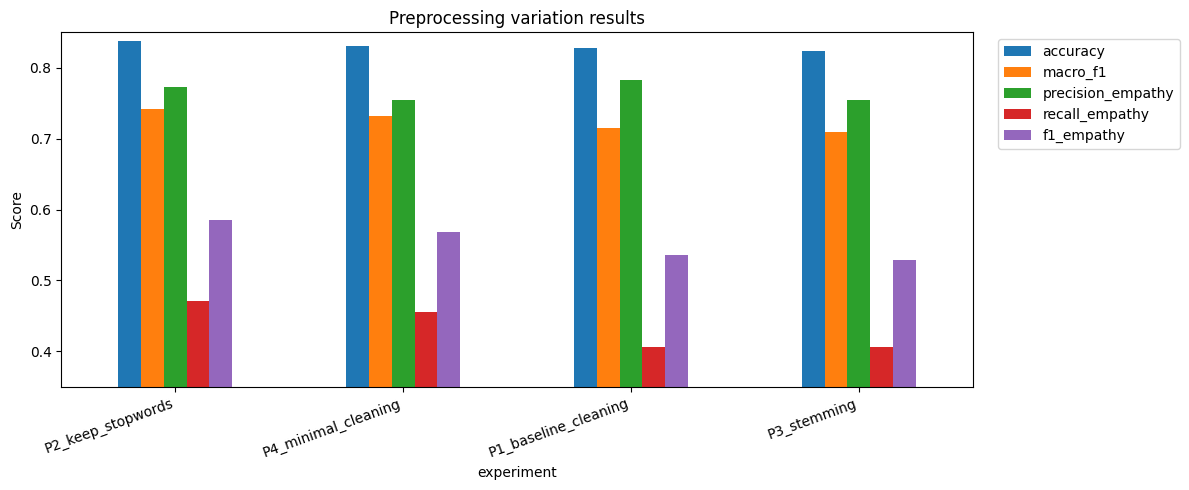

In [11]:
plot_df = results_df.set_index("experiment")[["accuracy", "macro_f1", "precision_empathy", "recall_empathy", "f1_empathy"]]

ax = plot_df.plot(kind="bar", figsize=(12, 5))
ax.set_title("Preprocessing variation results")
ax.set_ylabel("Score")
ax.set_ylim(0.35, 0.85)

plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

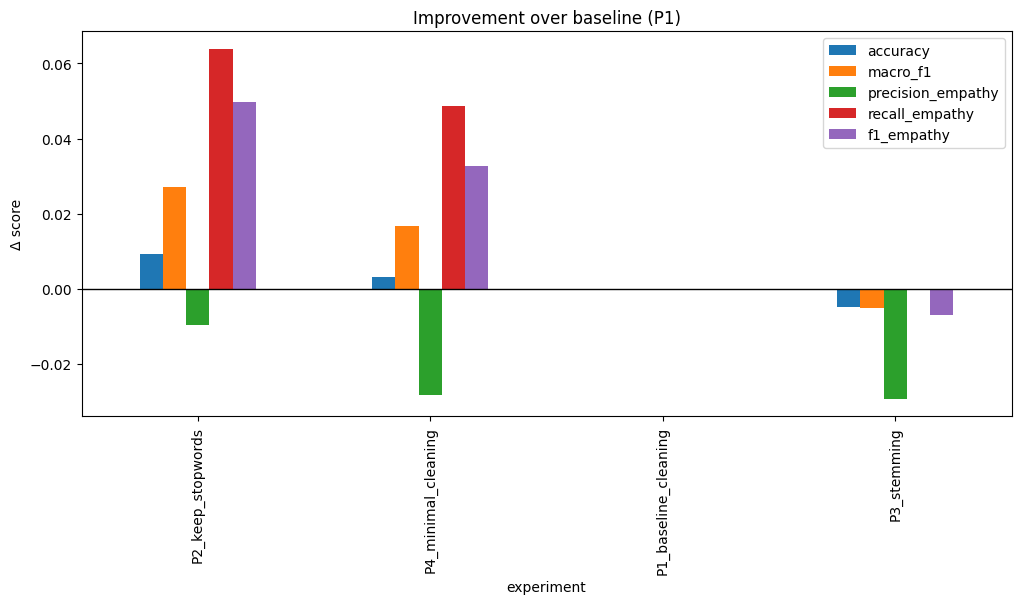

In [12]:
baseline = plot_df.loc["P1_baseline_cleaning"]  # baseline experiment

delta_df = plot_df - baseline

ax = delta_df.plot(kind="bar", figsize=(12,5))
ax.set_title("Improvement over baseline (P1)")
ax.set_ylabel("Δ score")
plt.axhline(0, color='black', linewidth=1)

## 14. Confusion matrices <a name = "cm"></a>

The confusion matrices help explain **why** a preprocessing variant performs better or worse.

For this task, the key question is whether a variant reduces the number of **false negatives** for empathy, since that was the main weakness of the classical baselines.

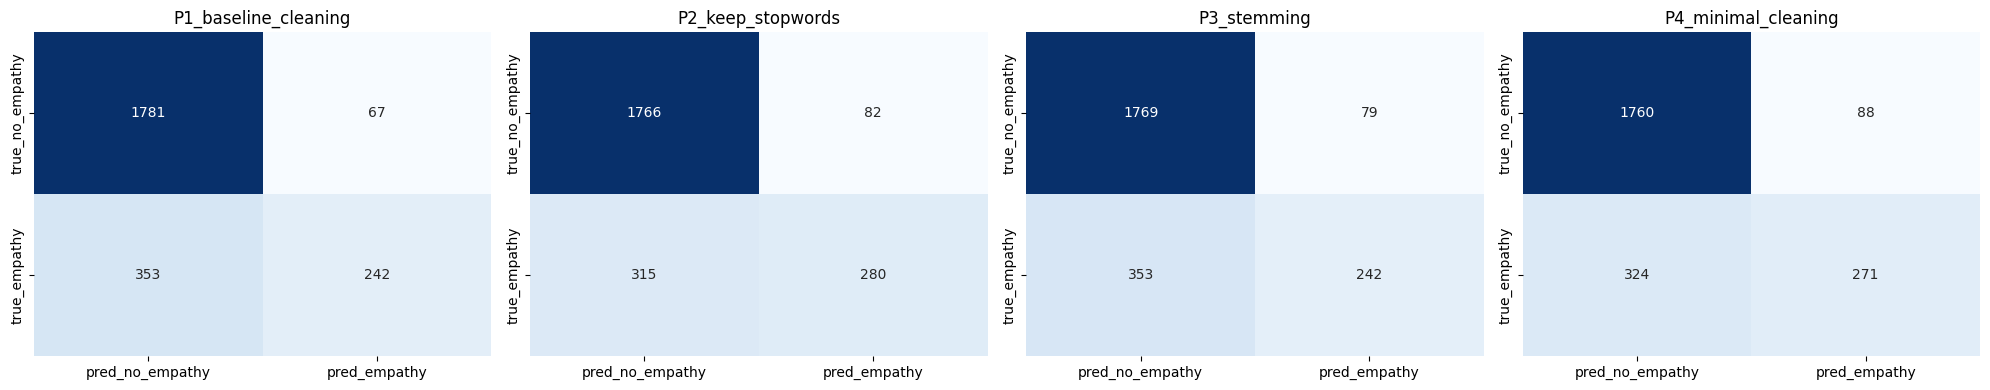

In [13]:
n_models = len(predictions)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:
    axes = [axes]

for ax, exp_name in zip(axes, PREPROCESSORS.keys()):
    y_pred = predictions[exp_name]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["pred_no_empathy", "pred_empathy"],
        yticklabels=["true_no_empathy", "true_empathy"],
    )
    ax.set_title(exp_name)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

---

# Conclusions <a name = "c"></a>

**Preprocessing has a clear impact**. The **best variant is P2_keep_stopwords**, achieving the highest Macro-F1 (0.742) and empathy recall (0.47). This **shows that removing stopwords hurts performance**, likely because empathy is expressed through pronouns and relational words (e.g., you, I, we).

P4_minimal_cleaning is the second-best, confirming that less aggressive cleaning preserves useful signal.

In contrast, P3_stemming performs worst, suggesting stemming is too aggressive and removes important distinctions.

Across all setups, empathy recall remains low, and confusion matrices show many false negatives. **This confirms that the main difficulty is still to be detected**.